# Wave Equation: Validation

Validates `wave.py`'s `leapfrog_step` (explicit finite-difference leapfrog
for `d^2(psi)/dt^2 = c^2 * laplacian(psi)`) and `cfl_dt` (the corrected 2D
CFL bound, fixing `legacy/`'s diffusion-style `dt` formula) two ways:

1. **Plane-wave propagation**: an analytic traveling sinusoid, evolved and
   compared to its exact analytic form away from the domain boundaries --
   both a direct correctness check and a 2nd-order convergence check.
2. **Standing-wave normal modes**: a Dirichlet box excited with an
   off-center pulse, FFT'd at an off-center observation point, compared to
   the analytic box-mode spectrum.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

import wave_eq as w

os.makedirs('media', exist_ok=True)

## Plane-wave propagation and convergence

Initialize the exact traveling wave `psi(x,y,t) = sin(kx*x - omega*t)`
(uniform in `y`) via `psi_curr = psi(t=0)`, `psi_prev = psi(t=-dt)`,
evolve for a few periods, and compare to the analytic waveform at a point
far enough from every edge that the Dirichlet-boundary mismatch (the
initial condition isn't zero at the edges, unlike the enforced boundary
condition) hasn't propagated in yet.

dx=0.1: rms error vs. analytic traveling wave = 0.19403


dx=0.05: rms error vs. analytic traveling wave = 0.04813


dx=0.025: rms error vs. analytic traveling wave = 0.01200
error ratios on halving dx: ['4.03', '4.01'] (expect ~4 for 2nd-order convergence)
PASS: plane wave propagates correctly and converges at 2nd order.


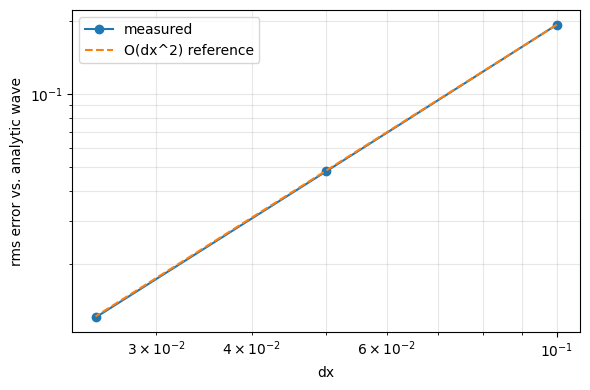

In [2]:
c = 1.0
kx = 2 * np.pi  # wavelength 1.0
omega = c * kx
T_period = 2 * np.pi / omega
n_periods = 3

resolutions = [0.1, 0.05, 0.025]
rms_errors = []
for dx in resolutions:
    dy = dx
    Nx = Ny = int(20 / dx)
    dt = w.cfl_dt(dx, dy, c, courant=0.5)
    n_steps = int(n_periods * T_period / dt)

    x = np.arange(Nx) * dx
    X, Y = np.meshgrid(x, x, indexing='ij')
    psi_curr = np.sin(kx * X)
    psi_prev = np.sin(kx * X + omega * dt)
    for _ in range(n_steps):
        psi_next = w.leapfrog_step(psi_prev, psi_curr, dt, dx, dy, c)
        psi_prev, psi_curr = psi_curr, psi_next

    t_final = n_steps * dt
    analytic = np.sin(kx * X - omega * t_final)
    ic = Nx // 2
    margin = int(5 / dx)  # stay well inside the region unaffected by boundary artifacts
    region = slice(ic - margin, ic + margin)
    err = psi_curr[region, Ny // 2] - analytic[region, Ny // 2]
    rms_errors.append(np.sqrt(np.mean(err**2)))
    print(f'dx={dx}: rms error vs. analytic traveling wave = {rms_errors[-1]:.5f}')

ratios = [rms_errors[i] / rms_errors[i + 1] for i in range(len(rms_errors) - 1)]
print(f'error ratios on halving dx: {[f"{r:.2f}" for r in ratios]} (expect ~4 for 2nd-order convergence)')
assert rms_errors[-1] < 0.02, 'finest-resolution propagation error is larger than expected'
assert all(3.0 < r < 5.0 for r in ratios), 'convergence rate is not consistent with the expected 2nd order'
print('PASS: plane wave propagates correctly and converges at 2nd order.')

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(resolutions, rms_errors, 'o-', label='measured')
ax.loglog(resolutions, rms_errors[0] * (np.array(resolutions) / resolutions[0])**2, '--', label='O(dx^2) reference')
ax.set_xlabel('dx'); ax.set_ylabel('rms error vs. analytic wave'); ax.legend(); ax.grid(alpha=0.3, which='both')
fig.tight_layout()
fig.savefig('media/wave_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

## Standing-wave normal modes

A rectangular Dirichlet box (`Lx x Ly`, physical size set by the array
extent since the solver forces `psi=0` at every edge), excited with a
small off-center Gaussian bump (so as many modes as possible get excited,
rather than only the symmetric ones). Recording `psi` at an off-center
point over a long run and taking its FFT should show peaks at the
analytic mode frequencies `omega_mn = c*pi*sqrt((m/Lx)^2 + (n/Ly)^2)`.

In [3]:
Nx, Ny = 120, 90
dx = dy = 0.05
c = 1.0
Lx, Ly = (Nx - 1) * dx, (Ny - 1) * dy

dt = w.cfl_dt(dx, dy, c, courant=0.4)
x = np.arange(Nx) * dx
y = np.arange(Ny) * dy
X, Y = np.meshgrid(x, y, indexing='ij')

x0, y0 = Lx * 0.3, Ly * 0.65
sigma = 0.15
psi0 = np.exp(-((X - x0)**2 + (Y - y0)**2) / (2 * sigma**2))
psi_curr, psi_prev = psi0.copy(), psi0.copy()

oi, oj = int(Nx * 0.4), int(Ny * 0.2)  # off-center observation point
n_steps = 20000
record = np.zeros(n_steps)
for step in range(n_steps):
    psi_next = w.leapfrog_step(psi_prev, psi_curr, dt, dx, dy, c)
    psi_prev, psi_curr = psi_curr, psi_next
    record[step] = psi_curr[oi, oj]

freqs = np.fft.rfftfreq(n_steps, d=dt) * 2 * np.pi
spec = np.abs(np.fft.rfft(record - record.mean()))

analytic omega=0.8816  nearest spectral peak=0.8886  rel. error=0.008
analytic omega=1.2702  nearest spectral peak=1.2662  rel. error=0.003
analytic omega=1.5074  nearest spectral peak=1.5106  rel. error=0.002
analytic omega=1.7342  nearest spectral peak=1.7549  rel. error=0.012
analytic omega=1.7632  nearest spectral peak=1.7549  rel. error=0.005
analytic omega=2.1219  nearest spectral peak=2.1104  rel. error=0.005
analytic omega=2.1828  nearest spectral peak=2.1770  rel. error=0.003
analytic omega=2.2269  nearest spectral peak=2.2214  rel. error=0.002
analytic omega=2.3666  nearest spectral peak=2.3547  rel. error=0.005
PASS: all 9 lowest box-mode frequencies match the analytic spectrum within 2%.


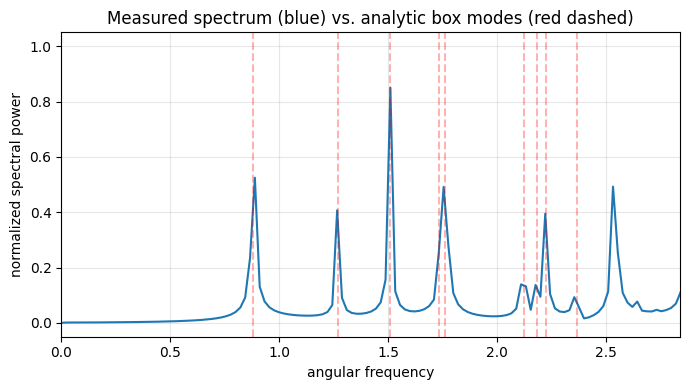

In [4]:
analytic_modes = sorted(
    c * np.pi * np.sqrt((m / Lx)**2 + (n / Ly)**2) for m in range(1, 6) for n in range(1, 6)
)[:9]

peaks, _ = find_peaks(spec, height=spec.max() * 0.03)
errs = []
for target in analytic_modes:
    idx = np.argmin(np.abs(freqs[peaks] - target))
    matched = freqs[peaks][idx]
    err = abs(matched - target) / target
    errs.append(err)
    print(f'analytic omega={target:.4f}  nearest spectral peak={matched:.4f}  rel. error={err:.3f}')

assert max(errs) < 0.02, 'a standing-wave mode frequency does not match the analytic prediction'
print('PASS: all 9 lowest box-mode frequencies match the analytic spectrum within 2%.')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(freqs, spec / spec.max())
for target in analytic_modes:
    ax.axvline(target, color='r', alpha=0.3, linestyle='--')
ax.set_xlim(0, max(analytic_modes) * 1.2)
ax.set_xlabel('angular frequency'); ax.set_ylabel('normalized spectral power')
ax.set_title('Measured spectrum (blue) vs. analytic box modes (red dashed)')
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('media/wave_standing_modes.png', dpi=150, bbox_inches='tight')
plt.show()